# Kaggle Titanic Dataset - EDA and Binary Classifier

### [Titanic - Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

Author: [Kevin Thomas](mailto:ket189@pitt.edu)

License: MIT

## Citation

[1] Kaggle, https://www.kaggle.com/c/titanic

[2] Data Science Dojo mirror, https://github.com/datasciencedojo/datasets

## Install Libraries

In [1]:
# conda activate prod
# conda install -c conda-forge pytorch torchvision torchaudio
# conda install numpy pandas matplotlib seaborn scikit-learn
# pip install kaggle

## What Is Kaggle

Kaggle is a platform for data science competitions and public datasets. A typical Kaggle project has five steps: create an account, download the data with the Kaggle API, explore the data, train a model, and submit predictions. This chapter walks through all five on the Titanic dataset, which asks you to predict which passengers survived.

## Create a Kaggle Account

1. Go to kaggle.com and sign up for a free account.
2. Open the Titanic competition at kaggle.com/c/titanic.
3. Click **Join Competition** to accept the rules and unlock the data.

## Get Your API Token

1. Click your profile picture, then **Settings**.
2. Under **API**, click **Create New Token**.
3. A file named `kaggle.json` downloads. Move it to `~/.kaggle/kaggle.json` and lock down its permissions.

In [2]:
# mkdir -p ~/.kaggle
# mv ~/Downloads/kaggle.json ~/.kaggle/kaggle.json
# chmod 600 ~/.kaggle/kaggle.json

## Download the Dataset With the Kaggle CLI

With the token in place, the Kaggle CLI downloads the competition files. The `train.csv` file has labels; `test.csv` does not, because Kaggle scores your predictions on its own hidden labels.

In [3]:
# kaggle competitions download -c titanic -f train.csv -p data
# kaggle competitions download -c titanic -f test.csv -p data
# kaggle competitions download -c titanic -f gender_submission.csv -p data

## Download With a Public Mirror

If you do not have a Kaggle token, this notebook falls back to a public mirror of the same Titanic training data so that it still runs end to end. The labeled file has 891 passengers, which we split ourselves.

## Import Libraries

In [4]:
import os
import urllib.request
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Seed

In [5]:
SEED = 42
SEED

42

In [6]:
torch.manual_seed(SEED)

## Download Dataset

### Function

In [7]:
def download_titanic(path='titanic.csv'):
    """
    Download the Titanic training data from a public mirror.

    Parameters:
        path (str): Destination CSV path.

    Returns:
        str: The path to the downloaded file.
    """
    url = ('https://raw.githubusercontent.com/datasciencedojo/'
           'datasets/master/titanic.csv')
    urllib.request.urlretrieve(url, path)
    return path

### Run

In [8]:
if not os.path.exists('titanic.csv'):
    download_titanic('titanic.csv')
print('downloaded titanic.csv')

downloaded titanic.csv


## Load Dataset

In [9]:
df = pd.read_csv('titanic.csv')

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Exploratory Data Analysis

### Dataset Shape and Types

In [11]:
print('rows:', df.shape[0])
print('columns:', df.shape[1])

rows: 891
columns: 12


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Summary Statistics

In [13]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Missing Values

`Age` and `Cabin` have many missing values. `Embarked` has only two. We will impute the numeric columns with the median and the categorical columns with the mode.

In [14]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Survival Rate

In [15]:
df['Survived'].value_counts(normalize=True).round(3)

Survived
0    0.616
1    0.384
Name: proportion, dtype: float64

### Survival by Sex

Women survived at a far higher rate than men. `Sex` is the strongest single predictor in this dataset.

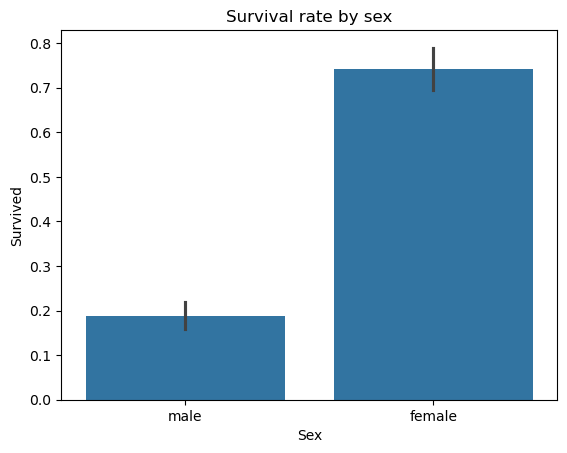

In [16]:
sns.barplot(data=df, x='Sex', y='Survived')
plt.title('Survival rate by sex')
plt.show()

### Survival by Passenger Class

First-class passengers survived more often than third-class passengers.

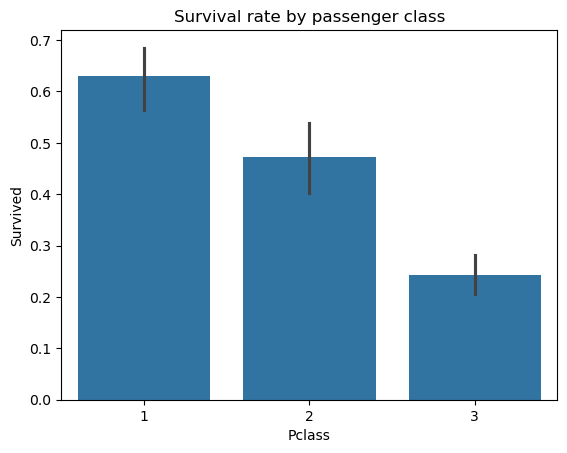

In [17]:
sns.barplot(data=df, x='Pclass', y='Survived')
plt.title('Survival rate by passenger class')
plt.show()

### Age Distribution

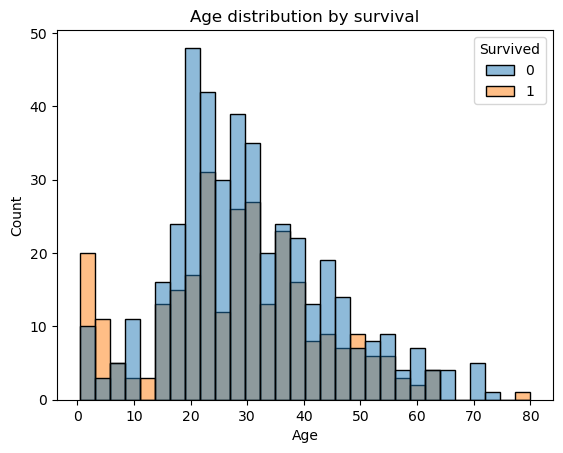

In [18]:
sns.histplot(data=df, x='Age', hue='Survived', bins=30)
plt.title('Age distribution by survival')
plt.show()

### Correlation Heatmap

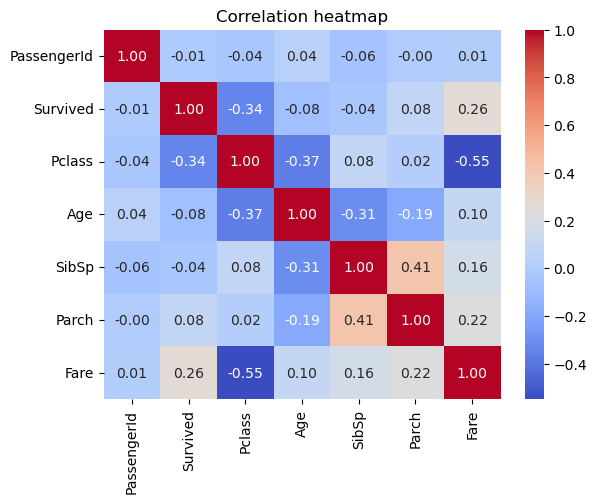

In [19]:
numeric = df.select_dtypes(include='number')
sns.heatmap(numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

## Feature Engineering

### Functions

In [20]:
def add_family_features(df):
    """
    Add family size and alone features.

    Parameters:
        df (pandas.DataFrame): The Titanic data.

    Returns:
        pandas.DataFrame: The data with new features.
    """
    df = df.copy()
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    return df


def impute_missing(df):
    """
    Fill missing values with medians and modes.

    Parameters:
        df (pandas.DataFrame): The Titanic data.

    Returns:
        pandas.DataFrame: The imputed data.
    """
    df = df.copy()
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    return df


def encode_features(df):
    """
    Encode categorical columns as numbers.

    Parameters:
        df (pandas.DataFrame): The Titanic data.

    Returns:
        pandas.DataFrame: The encoded data.
    """
    df = df.copy()
    df['Sex'] = (df['Sex'] == 'male').astype(int)
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    return df

### Run

In [21]:
df = add_family_features(df)
df = impute_missing(df)
df = encode_features(df)
df[['Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Embarked']].head()

,Sex,Age,Fare,FamilySize,IsAlone,Embarked
0,1,22.0,7.2500,2,0,0
1,0,38.0,71.2833,2,0,1
2,0,26.0,7.9250,1,1,0
3,0,35.0,53.1000,2,0,0
4,1,35.0,8.0500,1,1,0


## Prepare Features and Target

In [22]:
FEATURES = ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Embarked']
X = df[FEATURES].to_numpy(dtype=np.float32)
y = df['Survived'].to_numpy(dtype=np.int64)
X_MEAN = X.mean(axis=0)
X_STD = X.std(axis=0)
X = (X - X_MEAN) / X_STD
X.shape, y.shape

((891, 7), (891,))

## Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
X_train.shape, X_test.shape

((712, 7), (179, 7))

## Baseline Classifier: Logistic Regression

In [24]:
baseline = LogisticRegression(max_iter=1000).fit(X_train, y_train)
baseline_preds = baseline.predict(X_test)
baseline_probs = baseline.predict_proba(X_test)[:, 1]
print('accuracy:', round(accuracy_score(y_test, baseline_preds), 4))
print('roc auc :', round(roc_auc_score(y_test, baseline_probs), 4))

accuracy: 0.7933
roc auc : 0.8462


## PyTorch Classifier

### Device

In [25]:
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu")
DEVICE

device(type='mps')

### Create Dataset

In [26]:
class NumpyDataset(torch.utils.data.Dataset):
    """
    A memory-efficient dataset that stores data as NumPy arrays.
    """

    def __init__(self, X, y, device):
        """
        Initialize the dataset with NumPy arrays.

        Parameters:
            X (np.ndarray): Feature array.
            y (np.ndarray): Label array.
            device (torch.device): Device to move tensors to.

        Returns:
            None
        """
        self.X = X
        self.y = y
        self.device = device

    def __len__(self):
        """
        Return the number of samples in the dataset.

        Parameters:
            None

        Returns:
            int: Number of samples.
        """
        return len(self.X)

    def __getitem__(self, idx):
        """
        Return a single sample as tensors on the device.

        Parameters:
            idx (int): Index of the sample.

        Returns:
            tuple: Feature and label tensors.
        """
        X_tensor = torch.tensor(self.X[idx]).float().to(self.device)
        y_tensor = torch.tensor(self.y[idx]).long().to(self.device)
        return X_tensor, y_tensor

### Create Model

In [27]:
class Model(nn.Module):
    """
    A small feedforward classifier for tabular data.
    """

    def __init__(self, in_features, h1=32, h2=16, out_features=2):
        """
        Initialize the neural network layers.

        Parameters:
            in_features (int): Number of input features.
            h1 (int): Neurons in the first hidden layer.
            h2 (int): Neurons in the second hidden layer.
            out_features (int): Number of output features.

        Returns:
            None
        """
        super(Model, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, out_features))

    def forward(self, x):
        """
        Run the forward pass of the network.

        Parameters:
            x (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: Output logits.
        """
        return self.net(x)

### Create DataLoaders, Loss, and Optimizer

In [28]:
train_loader = DataLoader(NumpyDataset(X_train, y_train, DEVICE),
                          batch_size=32, shuffle=True)
test_loader = DataLoader(NumpyDataset(X_test, y_test, DEVICE),
                         batch_size=32, shuffle=False)
model = Model(len(FEATURES)).to(DEVICE)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
model

Model(
  (net): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)

### Functions

In [29]:
def train_epoch(model, loader, loss_fn, optimizer):
    """
    Train the model for a single epoch.

    Parameters:
        model (nn.Module): The model to train.
        loader (DataLoader): Training data loader.
        loss_fn (nn.Module): Loss function.
        optimizer (torch.optim.Optimizer): Parameter update rule.

    Returns:
        float: Mean training loss.
    """
    model.train()
    total = 0.0
    for x, y in loader:
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(y)
    return total / len(loader.dataset)


def evaluate(model, loader, loss_fn):
    """
    Evaluate the model over a loader.

    Parameters:
        model (nn.Module): The model to evaluate.
        loader (DataLoader): Evaluation data loader.
        loss_fn (nn.Module): Loss function.

    Returns:
        tuple: Mean loss and accuracy.
    """
    model.eval()
    total, correct = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            total += loss_fn(logits, y).item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
    n = len(loader.dataset)
    return total / n, correct / n

### Training Loop

In [30]:
for epoch in range(200):
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer)
    test_loss, test_accuracy = evaluate(model, test_loader, loss_fn)
    if (epoch + 1) % 40 == 0:
        print(f"Epoch {epoch + 1:3d} | loss {test_loss:.4f} | accuracy {test_accuracy:.4f}")

Epoch  40 | loss 0.4529 | accuracy 0.7989


Epoch  80 | loss 0.4894 | accuracy 0.8045


Epoch 120 | loss 0.6149 | accuracy 0.7821


Epoch 160 | loss 0.7025 | accuracy 0.7598


Epoch 200 | loss 0.8675 | accuracy 0.7709


## Evaluate the PyTorch Classifier

In [31]:
_, accuracy = evaluate(model, test_loader, loss_fn)
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.7709


In [32]:
model.eval()
with torch.no_grad():
    logits = model(torch.tensor(X_test, dtype=torch.float32).to(DEVICE))
    probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
preds = (probs >= 0.5).astype(int)
print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds, target_names=['died', 'survived']))

[[96 14]
 [27 42]]
              precision    recall  f1-score   support

        died       0.78      0.87      0.82       110
    survived       0.75      0.61      0.67        69

    accuracy                           0.77       179
   macro avg       0.77      0.74      0.75       179
weighted avg       0.77      0.77      0.77       179



### ROC Curve

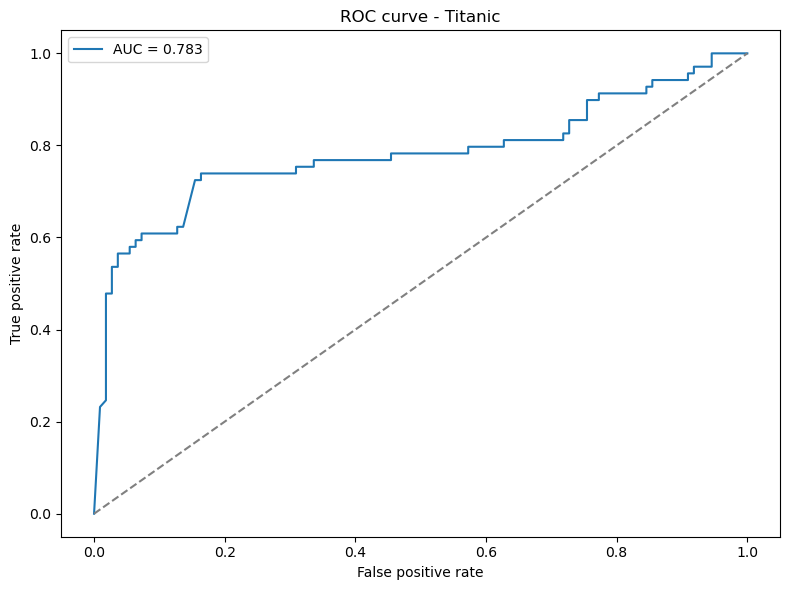

In [33]:
fpr, tpr, _ = roc_curve(y_test, probs)
auc_score = roc_auc_score(y_test, probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve - Titanic')
plt.legend()
plt.tight_layout()
plt.show()

## Create a Kaggle Submission

A Kaggle submission is a CSV with an `Id` column and the predicted labels. On the real competition you would use the provided `test.csv`, whose `Id` column matches `gender_submission.csv`.

### Function

In [34]:
def build_submission(ids, predictions, path='submission.csv'):
    """
    Write a Kaggle-format submission CSV.

    Parameters:
        ids (np.ndarray): Passenger ids.
        predictions (np.ndarray): Predicted survival labels.
        path (str): Output CSV path.

    Returns:
        str: The path to the submission file.
    """
    frame = pd.DataFrame({'PassengerId': ids, 'Survived': predictions})
    frame.to_csv(path, index=False)
    return path

### Run

In [35]:
indices = np.arange(len(df))
_, test_indices = train_test_split(indices, test_size=0.2, random_state=SEED, stratify=y)
test_ids = df['PassengerId'].to_numpy()[test_indices]
build_submission(test_ids, preds, 'submission.csv')
pd.read_csv('submission.csv').head()

,PassengerId,Survived
0,566,0
1,161,0
2,554,0
3,861,0
4,242,1


## Save Model

In [36]:
torch.save(model.state_dict(), 'kaggle_titanic.pt')
print('saved kaggle_titanic.pt')

saved kaggle_titanic.pt


## Load Model

In [37]:
loaded_model = Model(len(FEATURES)).to(DEVICE)
loaded_model.load_state_dict(torch.load('kaggle_titanic.pt', map_location=DEVICE))
loaded_model.eval()
print('loaded kaggle_titanic.pt')

loaded kaggle_titanic.pt


/var/folders/qg/60m3b34x32gczgr10l3665300000gn/T/ipykernel_74107/3707992541.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load('kagg

## Inference

### Function

In [38]:
def predict(model, features):
    """
    Predict survival for one passenger.

    Parameters:
        model (nn.Module): Trained model.
        features (list): Raw feature values in FEATURES order.

    Returns:
        tuple: Predicted label name and probability.
    """
    model.eval()
    scaled = (np.array(features, dtype=np.float32) - X_MEAN) / X_STD
    with torch.no_grad():
        X_new = torch.tensor(scaled).float().to(DEVICE).unsqueeze(0)
        probability = torch.softmax(model(X_new), dim=1)[0, 1].item()
    label = 'survived' if probability >= 0.5 else 'died'
    return label, probability

### Run

In [39]:
label, probability = predict(loaded_model, [3, 0, 25.0, 7.25, 1, 1, 0])
print(f"Predicted: {label} (p={probability:.4f})")

Predicted: died (p=0.4490)


## Submit to Kaggle

1. Open the Titanic competition page.
2. Click **Submit Predictions** and upload `submission.csv`.
3. Read your score on the public leaderboard.
4. Iterate on features and models to improve it.